# OCR Document Pipeline — Experiments
This notebook walks through the full pipeline visually:
1. Preprocessing steps (before/after)
2. OCR confidence analysis
3. Full extraction results

In [8]:
!git clone https://github.com/samy1406/ocr-document-pipeline.git
%cd ocr-document-pipeline
!pip install -r requirements.txt
!apt-get install -y tesseract-ocr poppler-utils

Cloning into 'ocr-document-pipeline'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 52 (delta 16), reused 28 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 557.57 KiB | 2.67 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/ocr-document-pipeline/ocr-document-pipeline
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [25]:
import sys
sys.path.append('src')

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import json
import preprocessor
import ocr_engine
import postprocessor

# Path to your sample invoice
IMAGE_PATH = 'data/sample_images/batch1-0001.jpg'

## Section 1 — Preprocessing Visualization
See what each preprocessing step does to the image.

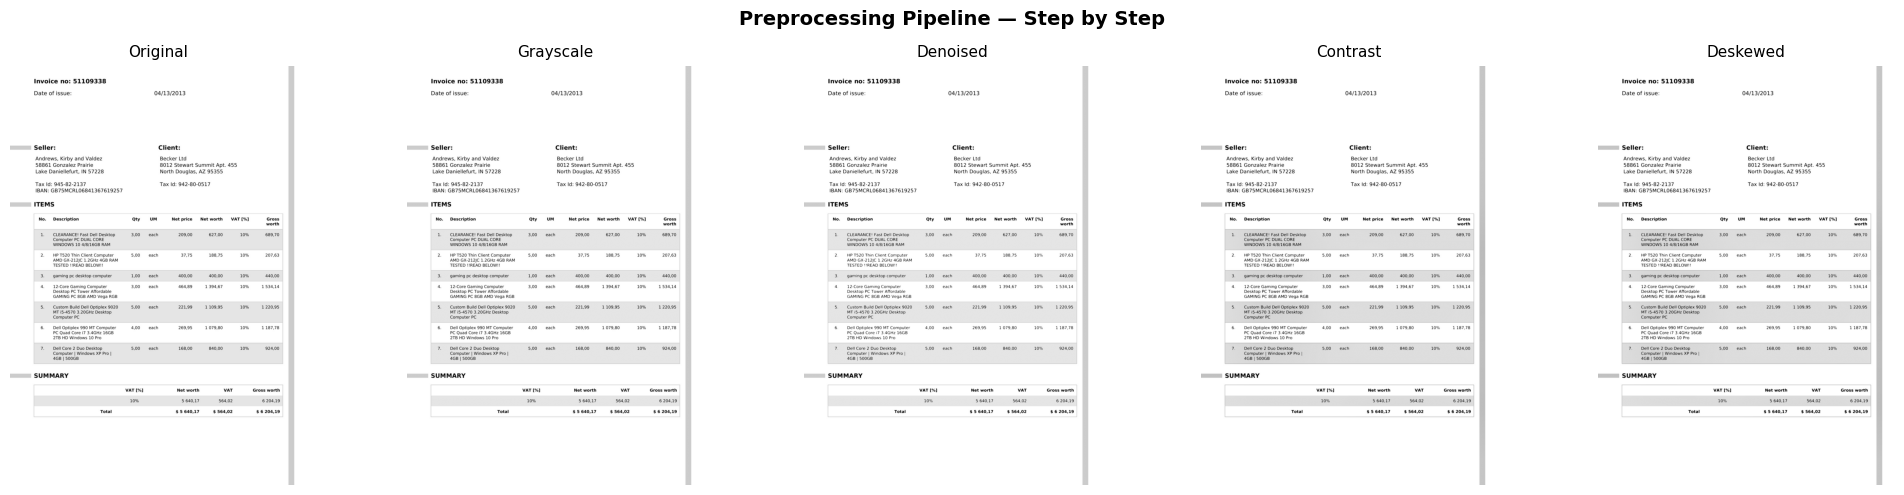

Saved to demo/preprocessing_steps_1.png


In [26]:
# Load and apply each step individually for visualization
original = preprocessor.load_image(IMAGE_PATH)
gray     = preprocessor.to_grayscale(original)
denoised = preprocessor.remove_noise(gray)
contrast = preprocessor.fix_contrast(denoised)
final    = preprocessor.fix_skew(contrast)

steps = [
    ('Original',   cv2.cvtColor(original, cv2.COLOR_BGR2RGB)),
    ('Grayscale',  gray),
    ('Denoised',   denoised),
    ('Contrast',   contrast),
    ('Deskewed',   final),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Preprocessing Pipeline — Step by Step', fontsize=14, fontweight='bold')

for ax, (title, img) in zip(axes, steps):
    cmap = 'gray' if img.ndim == 2 else None
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('demo/preprocessing_steps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to demo/preprocessing_steps_1.png')

## Section 2 — OCR Confidence Analysis
Tesseract gives a confidence score (0–100) for each word. Low confidence = OCR is unsure.

In [27]:
# Get structured OCR data with confidence scores
preprocessed = preprocessor.preprocess_image(IMAGE_PATH)
df = ocr_engine.image_to_data(preprocessed)

print(f'Total words detected (conf > 60): {len(df)}')
print(f'Average confidence: {df["conf"].mean():.1f}')
print(f'Min confidence: {df["conf"].min()}')
print(f'Max confidence: {df["conf"].max()}')
df.head(10)

Total words detected (conf > 60): 203
Average confidence: 93.8
Min confidence: 72
Max confidence: 96


,level,page_num,block_num,par_num,line_num,word_num,left,top,width,height,conf,text
4,5,1,1,1,1,1,136,77,130,26,95,Invoice
5,5,1,1,1,1,2,283,83,53,20,95,no:
6,5,1,1,1,1,3,353,77,181,26,95,51109338
10,5,1,2,1,1,1,136,146,69,22,96,Date
11,5,1,2,1,1,2,218,145,28,23,95,of
12,5,1,2,1,1,3,258,145,83,23,96,issue:
16,5,1,3,1,1,1,135,447,117,26,96,Seller:
20,5,1,4,1,1,1,142,511,126,22,96,"Andrews,"
21,5,1,4,1,1,2,282,510,67,27,96,Kirby
22,5,1,4,1,1,3,361,511,48,20,96,and


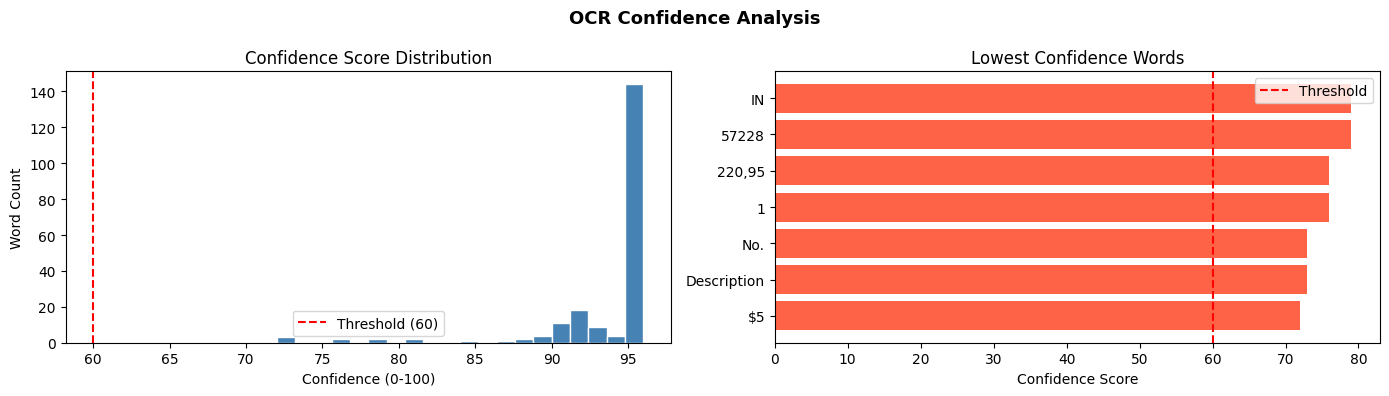

In [28]:
# Plot confidence score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('OCR Confidence Analysis', fontsize=13, fontweight='bold')

# Histogram
axes[0].hist(df['conf'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Confidence Score Distribution')
axes[0].set_xlabel('Confidence (0-100)')
axes[0].set_ylabel('Word Count')
axes[0].axvline(x=60, color='red', linestyle='--', label='Threshold (60)')
axes[0].legend()

# Low confidence words
low_conf = df[df['conf'] < 80].sort_values('conf').head(15)
if not low_conf.empty:
    axes[1].barh(low_conf['text'].astype(str), low_conf['conf'], color='tomato')
    axes[1].set_title('Lowest Confidence Words')
    axes[1].set_xlabel('Confidence Score')
    axes[1].axvline(x=60, color='red', linestyle='--', label='Threshold')
    axes[1].legend()

plt.tight_layout()
plt.show()

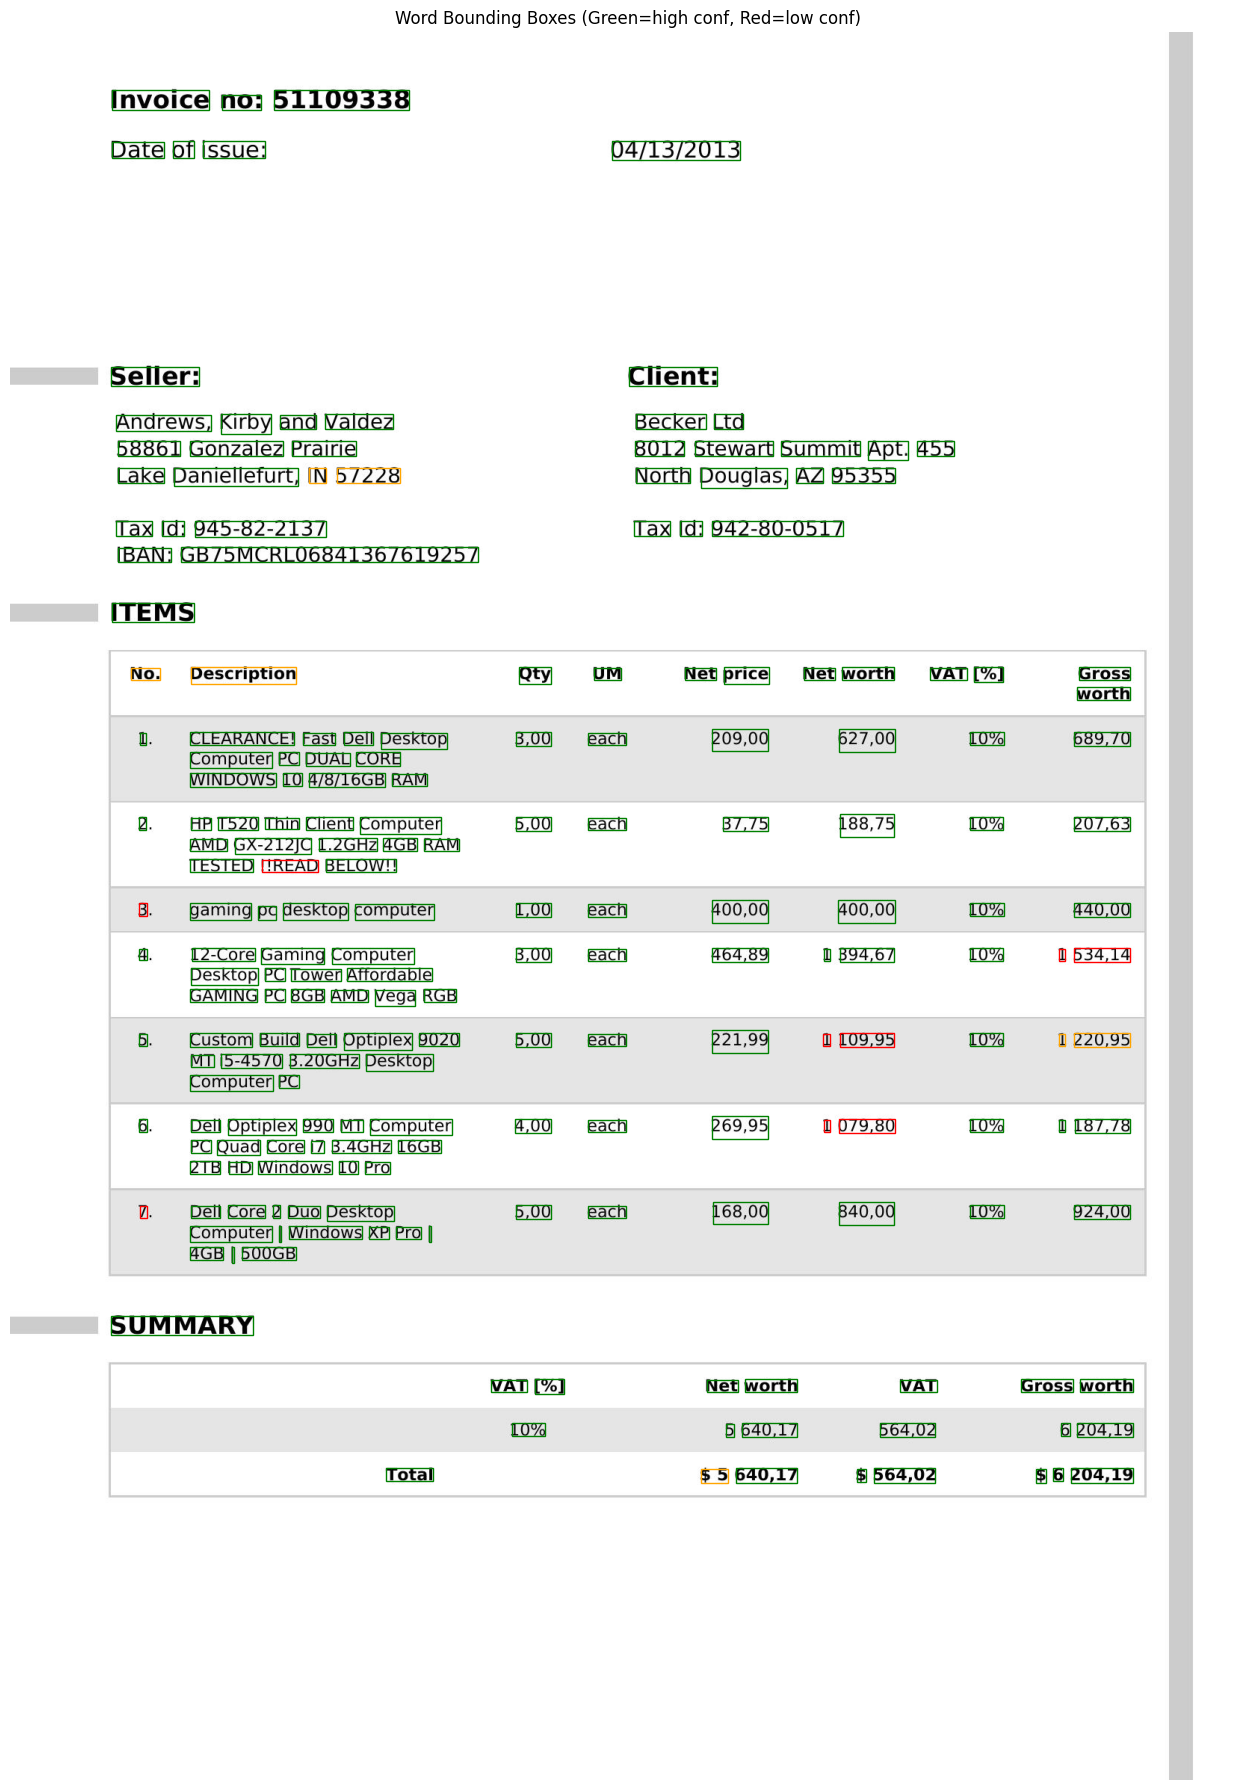

In [29]:
# Visualize bounding boxes on the image
# Green = high confidence, Red = low confidence
img_copy = cv2.cvtColor(preprocessor.load_image(IMAGE_PATH), cv2.COLOR_BGR2RGB).copy()

# Use raw data (all conf != -1) for bounding boxes
import pytesseract
raw_df = pytesseract.image_to_data(
    preprocessed,
    output_type=pytesseract.Output.DATAFRAME
)
raw_df = raw_df[raw_df['conf'] != -1]

fig, ax = plt.subplots(1, 1, figsize=(14, 18))
ax.imshow(img_copy)
ax.set_title('Word Bounding Boxes (Green=high conf, Red=low conf)', fontsize=12)

for _, row in raw_df.iterrows():
    x, y, w, h, conf = row['left'], row['top'], row['width'], row['height'], row['conf']
    color = 'green' if conf >= 80 else 'orange' if conf >= 60 else 'red'
    rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor=color, facecolor='none')
    ax.add_patch(rect)

ax.axis('off')
plt.tight_layout()
plt.show()

## Section 3 — Full Pipeline: Extraction Results

In [22]:
# Run full pipeline
raw_text = ocr_engine.image_to_text(preprocessed)

print('=== RAW OCR TEXT (first 500 chars) ===')
print(raw_text[:500])

=== RAW OCR TEXT (first 500 chars) ===
Invoice no: 12847181
Date of issue: 03/03/2012
Seller: Client:
Fitzpatrick and Sons Duncan PLC
00480 Cook Cove Unit 8799 Box 0703
Spencerport, UT 12036 DPO AP 81970
Tax Id: 998-99-5253 Tax Id: 911-82-7132
IBAN: GB92PBPQ73499358975916
ITEMS
No. Description Qty UM Net price Net worth VAT [%] Gross
worth
1 HP Desktop Computer PC 9) 4,00 each 139,95 559,80 10% 615,78
Core i5 16GB 2TB HD 256GB
SSD 22" LCD 9 Windows 10
2 CUSTOM BUILT AMD RYZEN 3,00 each 1 400,00 4 200,00 10% 4 620,00
THREADRIPPER GAMI


In [23]:
# Run postprocessing
cleaned = postprocessor.clean_text(raw_text)

result = {
    'date':         postprocessor.extract_date(cleaned),
    'address':      postprocessor.extract_address(cleaned),
    'products':     postprocessor.extract_product_names(cleaned),
    'descriptions': postprocessor.extract_line_item_descriptions(cleaned),
    'prices':       postprocessor.extract_prices(cleaned),
}

print('=== EXTRACTED FIELDS ===')
print(json.dumps(result, indent=2, default=str))

=== EXTRACTED FIELDS ===
{
  "date": "03/03/2012",
  "address": "Spencerport, UT 12036",
  "products": [
    [
      "22",
      "LCD 9 Windows 10 2 CUSTOM BUILT AMD RYZEN"
    ],
    [
      "3",
      "Fast Dell Optiplex Desktop PC"
    ],
    [
      "10",
      "Pro WIFI 4 Dell Optiplex 790 Computer i7"
    ],
    [
      "5",
      "Vintage Microsolutions Pentium"
    ]
  ],
  "descriptions": [
    "each",
    "CUSTOM BUILT AMD RYZEN",
    "Fast Dell Optiplex Desktop PC",
    "each",
    "each",
    "Vintage Microsolutions Pentium",
    "each"
  ],
  "prices": [
    " 4,00",
    " 139,95",
    " 559,80",
    " 615,78",
    " 3,00",
    " 400,00",
    " 200,00",
    " 620,00",
    " 1,00",
    " 217,00",
    " 217,00",
    " 238,70",
    " 3,00",
    " 159,99",
    " 479,97",
    " 527,97",
    " 3.40",
    " 2,00",
    " 390,00",
    " 780,00",
    " 858,00",
    " 5.25",
    " 236,77",
    " 623,68",
    " 860,45",
    " 236,77",
    "$ 623,68",
    " 860,45"
  ]
}


In [24]:
# Summary table
print('=== EXTRACTION SUMMARY ===')
print(f"Date found     : {result['date']}")
print(f"Address found  : {result['address']}")
print(f"Products found : {len(result['products'])}")
for i, p in enumerate(result['products'], 1):
    print(f"  {i}. {p}")
print(f"Prices found   : {len(result['prices'])}")
print(f"  → {result['prices']}")

=== EXTRACTION SUMMARY ===
Date found     : 03/03/2012
Address found  : Spencerport, UT 12036
Products found : 4
  1. ('22', 'LCD 9 Windows 10 2 CUSTOM BUILT AMD RYZEN')
  2. ('3', 'Fast Dell Optiplex Desktop PC')
  3. ('10', 'Pro WIFI 4 Dell Optiplex 790 Computer i7')
  4. ('5', 'Vintage Microsolutions Pentium')
Prices found   : 28
  → [' 4,00', ' 139,95', ' 559,80', ' 615,78', ' 3,00', ' 400,00', ' 200,00', ' 620,00', ' 1,00', ' 217,00', ' 217,00', ' 238,70', ' 3,00', ' 159,99', ' 479,97', ' 527,97', ' 3.40', ' 2,00', ' 390,00', ' 780,00', ' 858,00', ' 5.25', ' 236,77', ' 623,68', ' 860,45', ' 236,77', '$ 623,68', ' 860,45']


## What I Learned

**Preprocessing matters most:**
- CLAHE handled uneven lighting better than simple thresholding
- `medianBlur` preserved text edges better than Gaussian for documents

**Tesseract PSM modes:**
- PSM 6 (uniform block of text) worked best for invoices
- PSM 11 (sparse text) would work better for scattered labels

**Regex limitations:**
- `clean_text` was stripping `/` which broke date extraction — order of operations matters
- European price format (`,` as decimal) requires `[.,]` not just `\.`
- Quantities and prices share the same format — regex alone cannot distinguish them

**Next step for production:**
- Use LayoutLM or Donut model for document understanding — these use spatial position + text together, solving the quantity-vs-price problem regex cannot handle